Dataset shape: (150, 4)

SOM training completed.


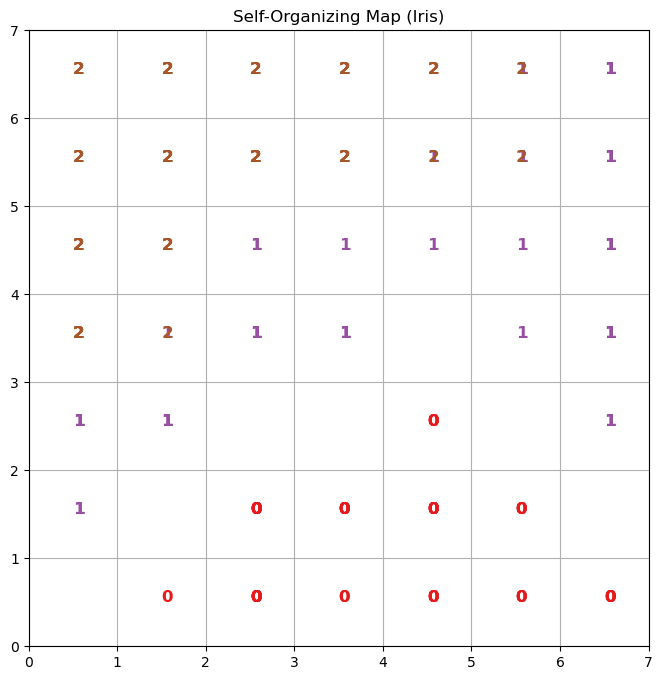

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom


# ---- Step 1: Load dataset (Iris) ----
iris = load_iris(as_frame=True)

X = iris.data.values
y = iris.target.values

print("Dataset shape:", X.shape)


# ---- Step 2: Normalize features (SOM needs values between 0 and 1) ----
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


# ---- Step 3: Initialize SOM ----
som_size = 7

som = MiniSom(
    x=som_size,
    y=som_size,
    input_len=X_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)


# ---- Step 4: Train SOM ----
som.random_weights_init(X_scaled)

som.train_random(
    X_scaled,
    num_iteration=1000
)

print("\nSOM training completed.")


# ---- Step 5: Visualization ----
plt.figure(figsize=(8, 8))

for i, x in enumerate(X_scaled):

    w = som.winner(x)

    plt.text(
        w[0] + 0.5,
        w[1] + 0.5,
        str(y[i]),
        color=plt.cm.Set1(y[i] / 3.0),
        fontdict={
            "weight": "bold",
            "size": 12
        }
    )


plt.title("Self-Organizing Map (Iris)")
plt.xlim([0, som_size])
plt.ylim([0, som_size])
plt.grid(True)

plt.show()

In [5]:
!pip install minisom pandas scikit-learn matplotlib numpy